# TL;DR

- This is a notebook with a quite short discovery of main crypto assets (those with options on binance): BTC, ETH, SOL, BNB, XRP, DOGE
- 

# Outline

- [Libs](#libs)
- [Data](#data)
- [Returns EDA](#returns-eda)
- [Baseline](#baseline)
- [Strategies](#strategies)
    - [Markowitz optimal portfolio](#markowitz-optimal-portfolio)
    - [Momentum](#momentum)

# Libs

In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
from utils import max_sharpe_weights, equiry_curve, emama

%matplotlib inline

# Data

In [96]:
df = pd.read_csv('data/spot_data.csv')

In [97]:
df.head()

,date,open_price,high_price,low_price,close_price,volume,symbol
0,2019-01-01,3701.23,3810.16,3642.00,3797.14,23741.687033,BTCUSDT
1,2019-01-02,3796.45,3882.14,3750.45,3858.56,35156.463369,BTCUSDT
2,2019-01-03,3857.57,3862.74,3730.00,3766.78,29406.948359,BTCUSDT
3,2019-01-04,3767.20,3823.64,3703.57,3792.01,29519.554671,BTCUSDT
4,2019-01-05,3790.09,3840.99,3751.00,3770.96,30490.667751,BTCUSDT


In [98]:
df.columns

Index(['date', 'open_price', 'high_price', 'low_price', 'close_price',
       'volume', 'symbol'],
      dtype='object')

In [99]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 711260 entries, 0 to 711259
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         711260 non-null  object 
 1   open_price   711260 non-null  float64
 2   high_price   711260 non-null  float64
 3   low_price    711260 non-null  float64
 4   close_price  711260 non-null  float64
 5   volume       711260 non-null  float64
 6   symbol       711260 non-null  object 
dtypes: float64(5), object(2)
memory usage: 38.0+ MB


In [100]:
df.date = pd.to_datetime(df.date)

In [101]:
# currently there are BTC, ETH, SOL, BNB, XRP, DOGE options on binance
option_symbols = ['BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'BNBUSDT', 'XRPUSDT', 'DOGEUSDT']

In [102]:
df = df[df.symbol.isin(option_symbols)]

In [103]:
df = df.reset_index(drop=True)

In [104]:
# .groupby().pct_change() works weird, so using apply() with multiplying by 100
# we might need df with OHLC candles, creating a new DataFrame
ret = df.set_index('date')[['symbol', 'close_price']].groupby('symbol').apply(lambda x: (x/x.shift()-1)*100).reset_index().dropna().rename(columns = {'close_price':'returns'}).set_index('date').copy()

# Returns EDA

<Axes: xlabel='date'>

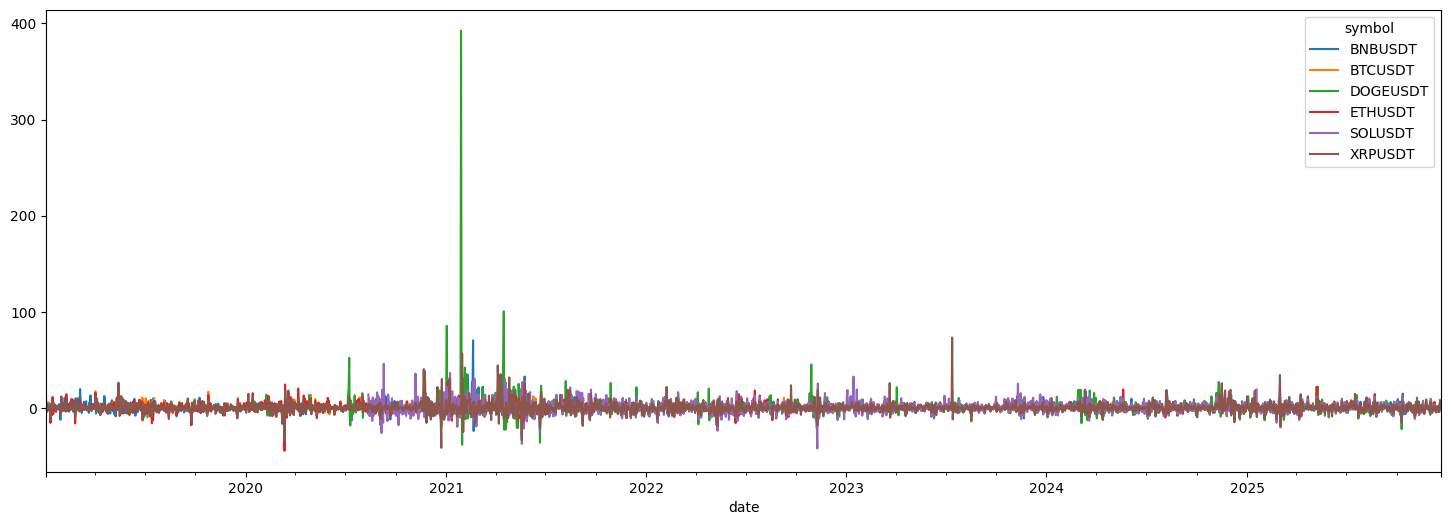

In [105]:
ret.pivot(columns='symbol', values='returns').plot(figsize=(18, 6))

- Looks completely uninformative
- Let's go to histogram 

array([[<Axes: title={'center': 'BNBUSDT'}>,
        <Axes: title={'center': 'BTCUSDT'}>],
       [<Axes: title={'center': 'DOGEUSDT'}>,
        <Axes: title={'center': 'ETHUSDT'}>],
       [<Axes: title={'center': 'SOLUSDT'}>,
        <Axes: title={'center': 'XRPUSDT'}>]], dtype=object)

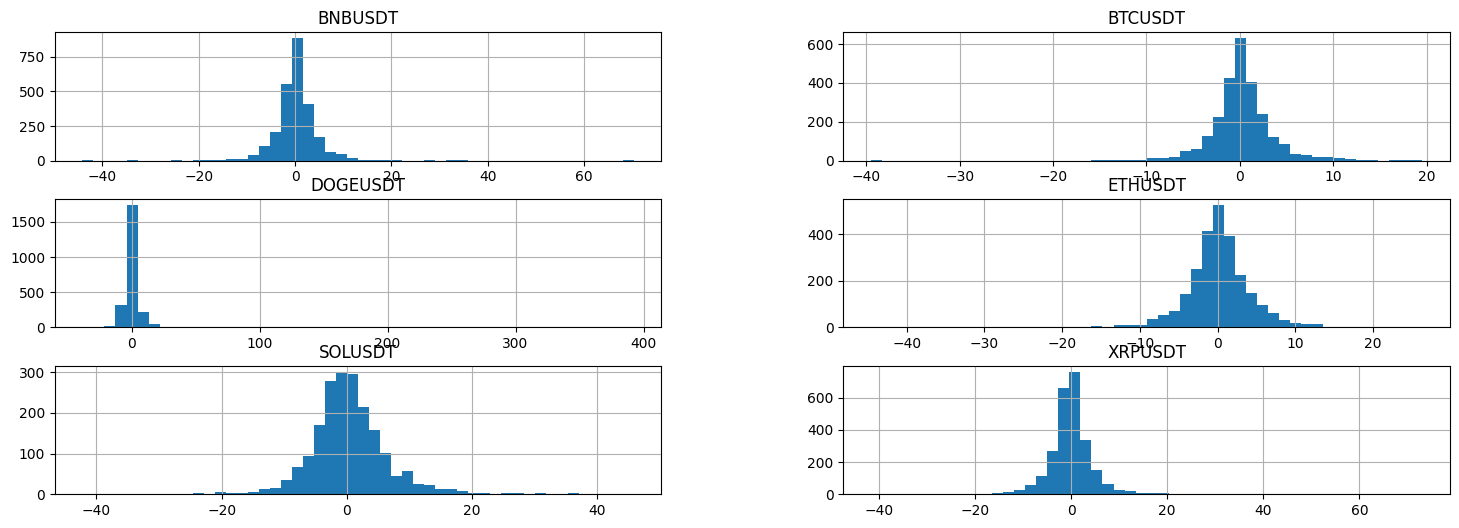

In [106]:
ret.pivot(columns='symbol', values='returns').hist(figsize=(18, 6), bins=50)

- Default pandas (matplotlib) histogram looks horrible
- Let's do something more useful

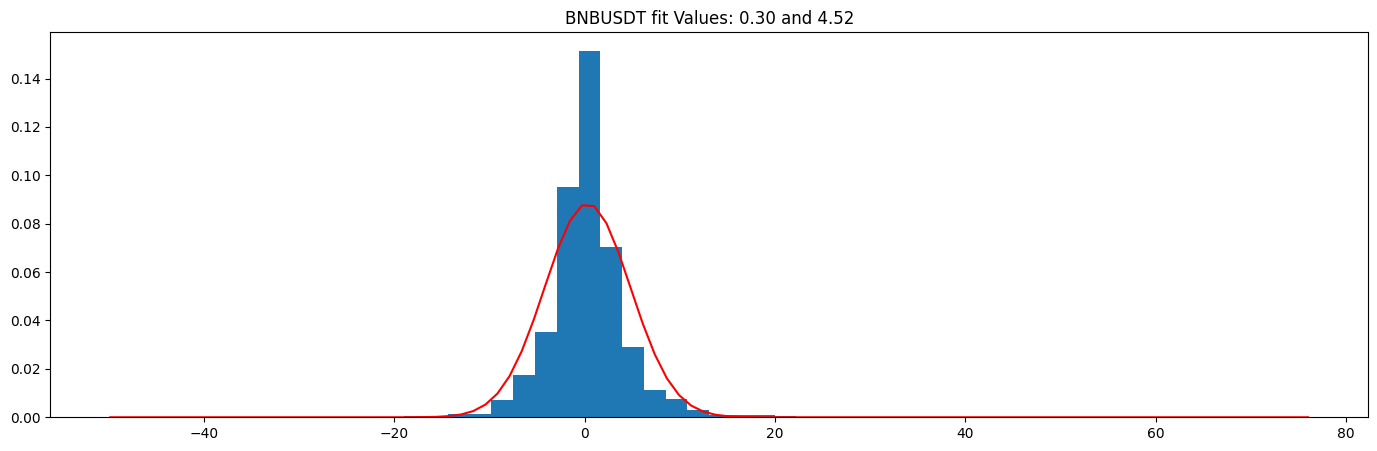

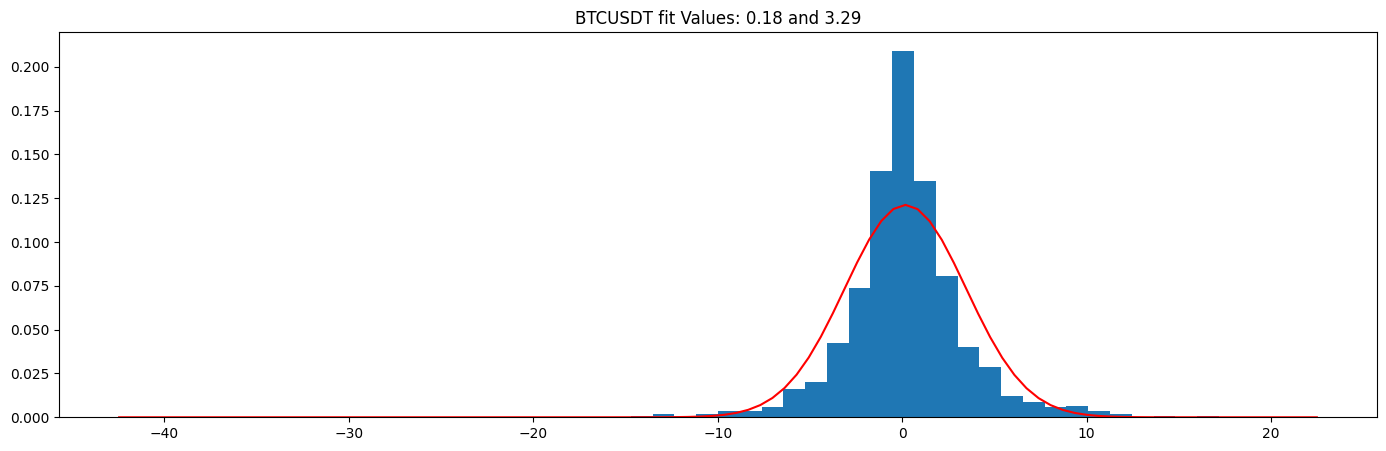

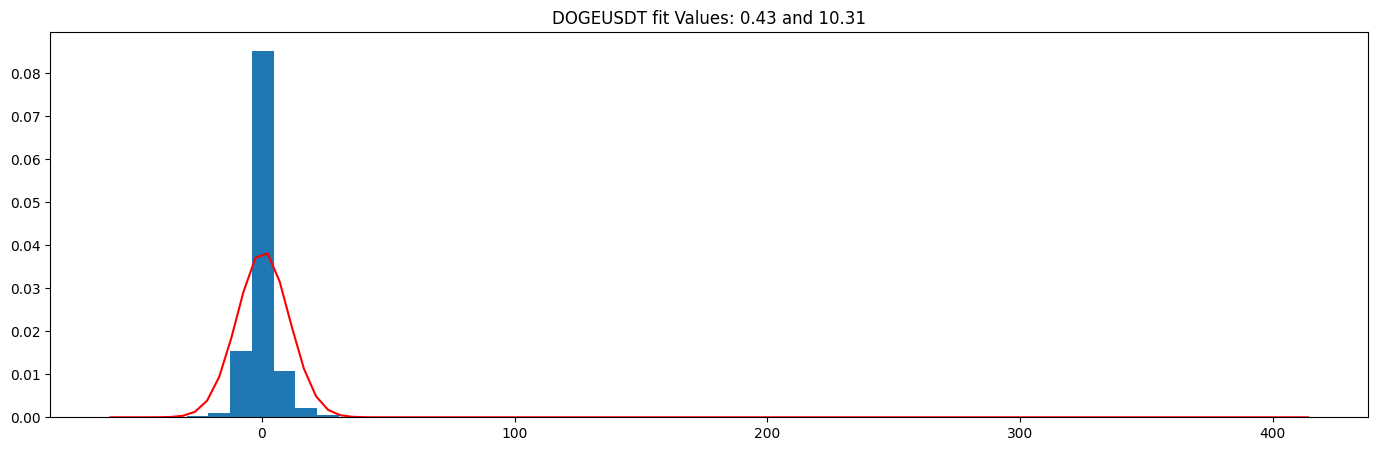

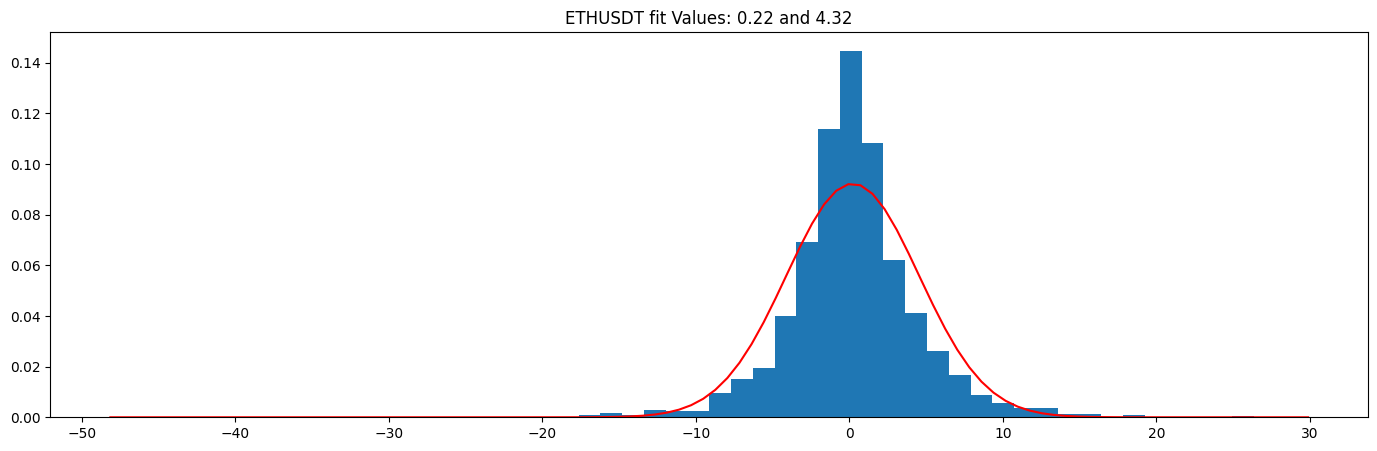

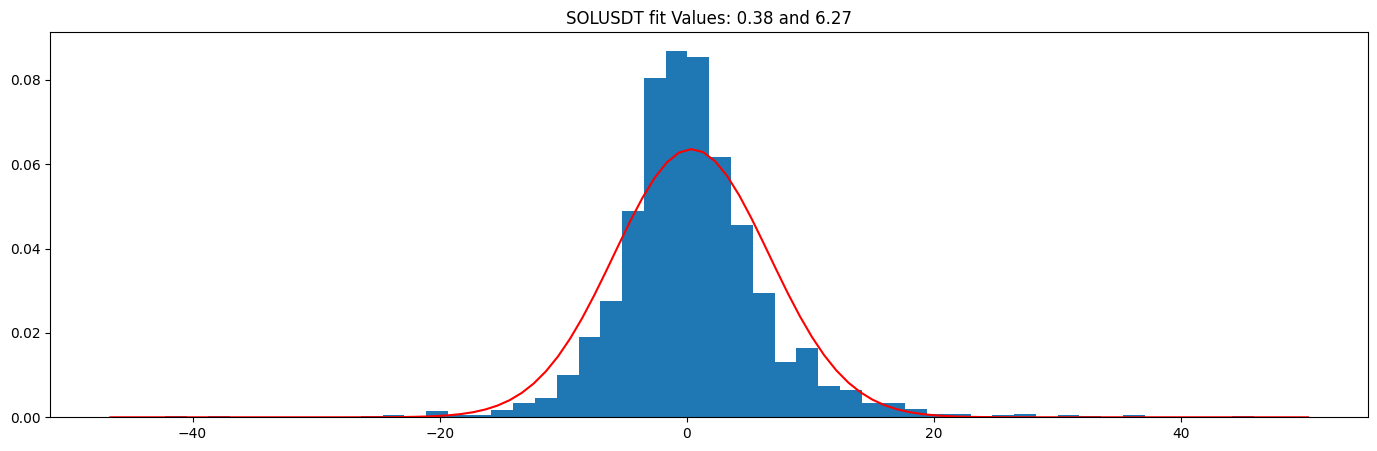

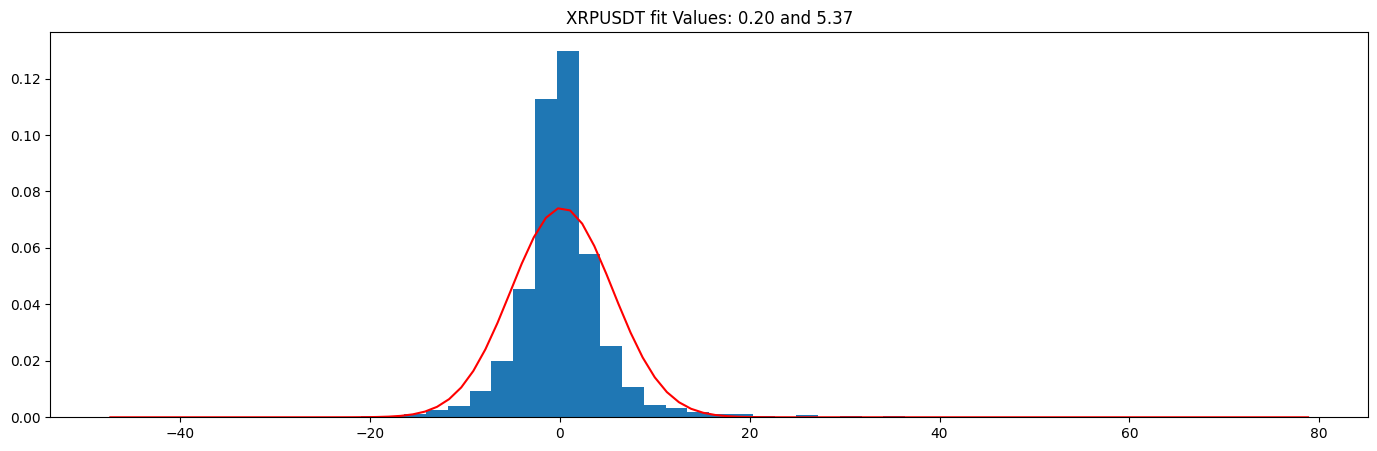

In [107]:
for symbol in ret.symbol.unique():
    
    tmp = ret[ret.symbol == symbol]['returns']

    mu, std = stats.norm.fit(tmp)
    
    plt.figure(figsize=(17,5))
    plt.hist(tmp, bins=50, density=True)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)

    plt.plot(x, p, 'r')
    title = f"{symbol} fit Values: {mu:.2f} and {std:.2f}"
    plt.title(title)

    plt.show()

In [108]:
ret.groupby('symbol').describe()

returns                                                      \
           count      mean        std        min       25%       50%   
symbol                                                                 
BNBUSDT   2546.0  0.295178   4.518315 -44.138077 -1.556955  0.164437   
BTCUSDT   2546.0  0.178705   3.292418 -39.504847 -1.288894  0.056268   
DOGEUSDT  2361.0  0.434617  10.313626 -38.439286 -2.370864 -0.034823   
ETHUSDT   2546.0  0.215533   4.325051 -44.596886 -1.838836  0.104701   
SOLUSDT   1958.0  0.380570   6.276309 -42.247744 -2.970316 -0.002174   
XRPUSDT   2546.0  0.202994   5.374945 -41.646880 -1.949394  0.021963   

                                
               75%         max  
symbol                          
BNBUSDT   1.969779   70.302147  
BTCUSDT   1.546463   19.536139  
DOGEUSDT  2.124743  392.411365  
ETHUSDT   2.156087   26.332887  
SOLUSDT   3.255592   45.871151  
XRPUSDT   1.953486   73.099788

In [109]:
ret.groupby('symbol').apply(pd.DataFrame.skew)

,returns
symbol,
BNBUSDT,1.478063
BTCUSDT,-0.383096
DOGEUSDT,24.132410
ETHUSDT,-0.197382
SOLUSDT,0.588339
XRPUSDT,2.262593


In [110]:
ret.groupby('symbol').apply(pd.DataFrame.kurt)

,returns
symbol,
BNBUSDT,32.184917
BTCUSDT,11.468535
DOGEUSDT,890.627724
ETHUSDT,8.405213
SOLUSDT,6.239019
XRPUSDT,28.379657


- Obviously we won't go deep into non normal distributions with heavy tails (this is not prod level discovery), but, damn, we definitely need t-Student, GED or any other heavy-tailed distribution
- Doge is just a monster with such skewness and kurtosis
- We are going to use quite simple techniques at first, but it is obvious that "ordinary" statistical methods are going to have a hard time

- It is also a good practice to see how statistics evolve through time

In [111]:
WINDOW_SIZE = 365 # using 1 year window

<Axes: title={'center': 'Mean'}, xlabel='date'>

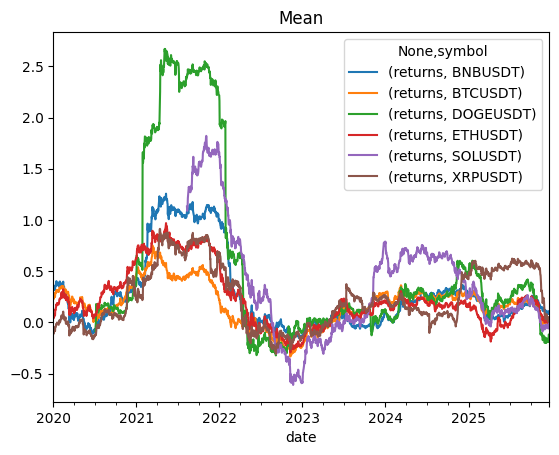

In [112]:
ret.groupby('symbol').rolling(WINDOW_SIZE).mean().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot(title = 'Mean')

<Axes: title={'center': 'Standard deviation'}, xlabel='date'>

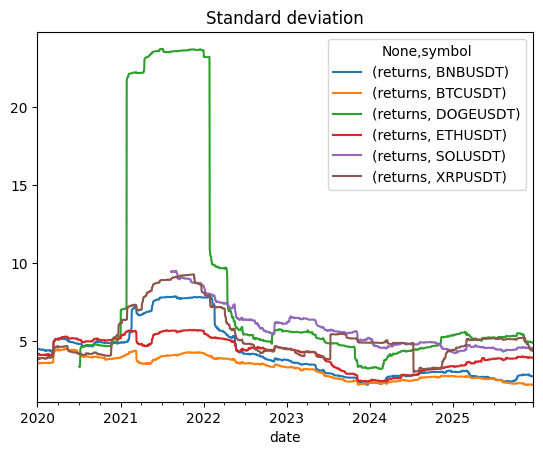

In [113]:
ret.groupby('symbol').rolling(WINDOW_SIZE).std().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot(title = 'Standard deviation')

<Axes: title={'center': 'Skewness'}, xlabel='date'>

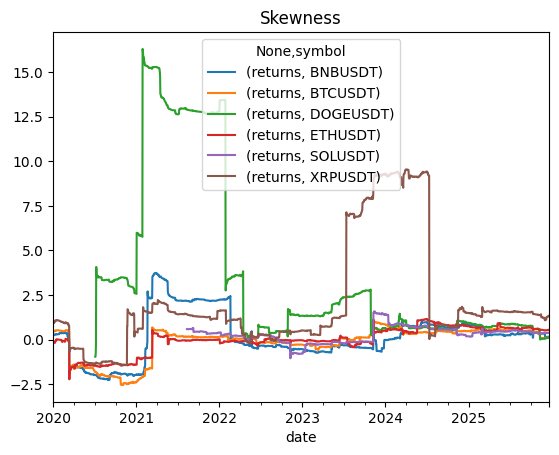

In [114]:
ret.groupby('symbol').rolling(WINDOW_SIZE).skew().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot(title = 'Skewness')

<Axes: title={'center': 'Kurtosis'}, xlabel='date'>

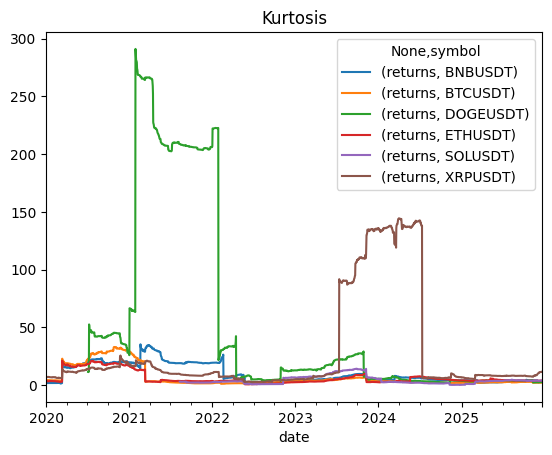

In [115]:
ret.groupby('symbol').rolling(WINDOW_SIZE).kurt().reset_index().dropna().set_index('date').pivot(columns = 'symbol').plot(title = 'Kurtosis')

- Well, it looks like a disaster 
- Mean and standard deviation is one story, but the way skewness and kurtosis changes is a whole other story
- Conclusion is actually quite simple, distribution of returns changes over time and quite rapidly 
- This is very important insight that we can use further

- At last let's see what would we have got with simple buy and hold for each asset

In [116]:
# First, making sure that everything has the same start date (I am just lazy)
ret = ret[ret.index >= ret.reset_index().groupby('symbol')['date'].min().max()]

<Axes: xlabel='date'>

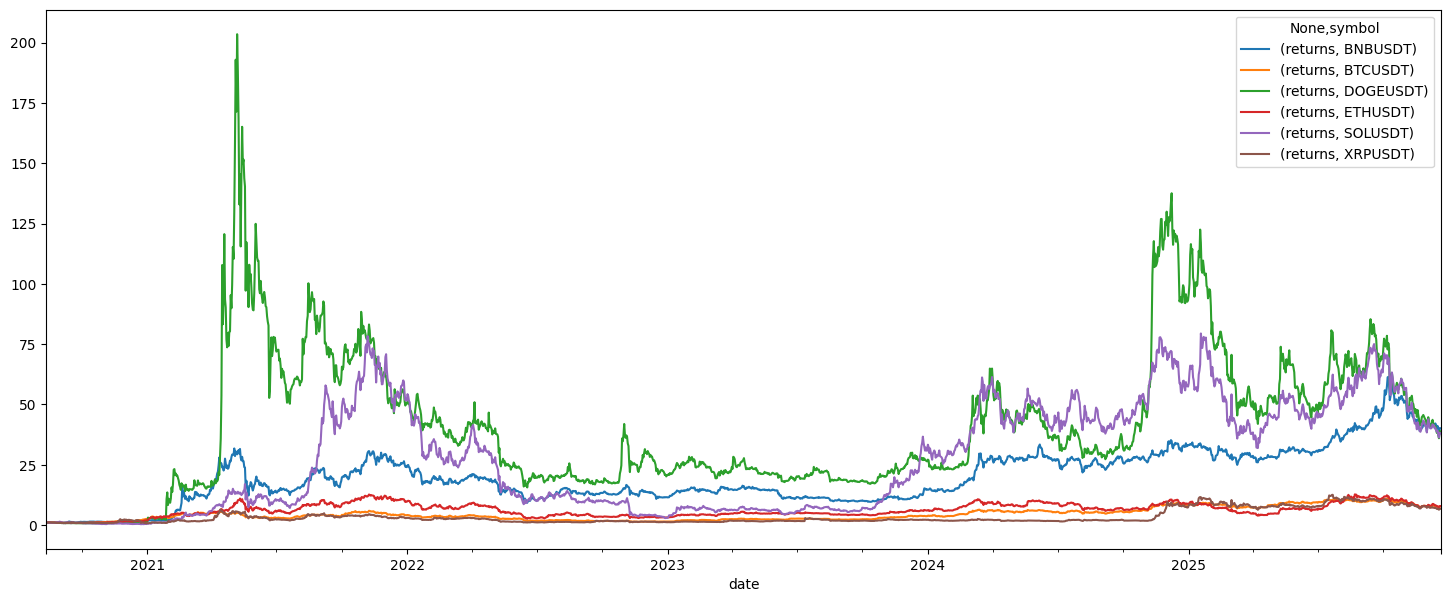

In [117]:
ret.groupby('symbol').apply(lambda x: (1+x/100).cumprod()).reset_index().set_index('date').pivot(columns='symbol').plot(figsize=(18, 7))

- Would have been nice to get 200x...
- Anyway, this is just a fun activity showing how volatile these assets are and how the nature of crypto market changes in no time
- The main challenge is creating not just profitable strategy, but one that keeps up with changing market conditions

# Baseline

- The simplest baseline is an equally weighted long portfolio of these assets

In [118]:
w_baseline = 1/len(ret.symbol.unique())

In [119]:
baseline_portfolio = (ret.pivot(columns = 'symbol') * w_baseline).sum(axis=1)

In [120]:
baseline_portfolio = pd.DataFrame(baseline_portfolio).rename(columns = {0:'returns'})
baseline_portfolio['symbol'] = 'baseline'

In [121]:
baseline_portfolio = baseline_portfolio[['symbol', 'returns']]

In [122]:
ret = pd.concat([ret, baseline_portfolio], axis = 0)

<Axes: xlabel='date'>

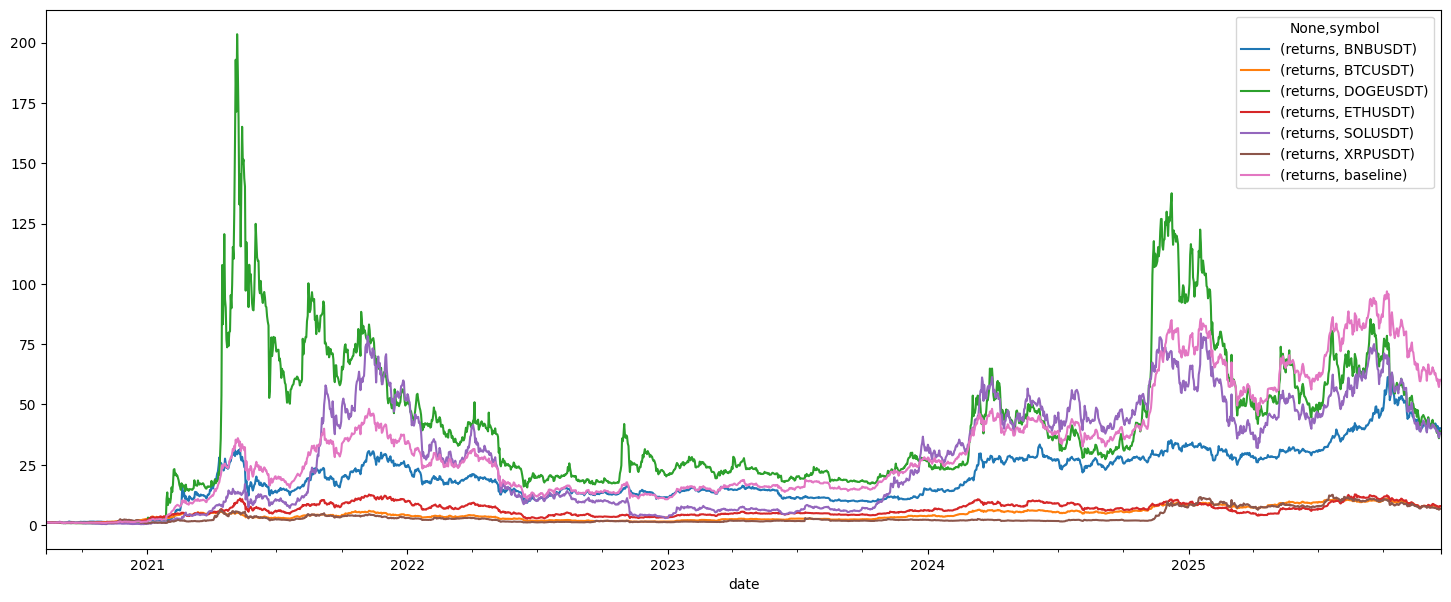

In [123]:
ret.groupby('symbol').apply(lambda x: (1+x/100).cumprod()).reset_index().set_index('date').pivot(columns='symbol').plot(figsize=(18, 7))

- Ok, we have a baseline portfolio
- Now, how would we decide that our strategy is better or worse that buy and hold of baseline portfolio?
- There are a lot of metrics, but I prefer returns to 95% expected shortfall (ES95%) - return to risk ratio (RRR) for future reference

In [124]:
baseline_ret = (1+baseline_portfolio.returns/100).prod()
baseline_avg_ret = baseline_portfolio.returns.mean()
baseline_es95 = baseline_portfolio[baseline_portfolio.returns < baseline_portfolio.returns.quantile(0.05)].returns.mean()

In [125]:
print(f'''
    For the period from {baseline_portfolio.index.min().date().strftime('%Y-%m-%d')} to {baseline_portfolio.index.max().date().strftime('%Y-%m-%d')} \n
    baseline metrics are: \n
        cumulative return is {baseline_ret:.2f}% \n
        average return is {baseline_avg_ret:.2f}% \n
        ES95% is {baseline_es95:.2f}% \n
        cumulative RRR is {baseline_ret / abs(baseline_es95):.2f} \n
        average RRR is {baseline_avg_ret / abs(baseline_es95):.2f}
    '''
)


    For the period from 2020-08-12 to 2025-12-21 

    baseline metrics are: 

        cumulative return is 59.98% 

        average return is 0.29% 

        ES95% is -8.94% 

        cumulative RRR is 6.71 

        average RRR is 0.03
    


# Strategies

- Well, this is the most difficult part actually
- Let's look at this problem at two different angles 
- The first angle is a optimal portfolio theory. Basically, let's implement Markowitz portfolio theory. Again, I will use a 1 year rolling window basis for weights recalculation
- The second angle is a true cypro bros approach (actually, classic momentum): if EMA 5 > EMA 25 -> buy, weights will be volatility proportioned 
- No short positions allowed (as I said earlier, I am lazy)

## Markowitz optimal portfolio

In [126]:
w_uncon = max_sharpe_weights(ret[ret.symbol!='baseline'].pivot(columns='symbol'))

In [127]:
w_cap = max_sharpe_weights(ret[ret.symbol!='baseline'].pivot(columns='symbol'), max_w = 0.3)

In [128]:
w_tbl = pd.DataFrame(
    {"Max Sharpe ratio":w_uncon, 'Max Sharpe ratio with cap 0.3':w_cap}, 
    index = option_symbols
    ).round(3)

In [129]:
eq_uncon, pr_uncon = equiry_curve(ret[ret.symbol!='baseline'].pivot(columns='symbol'), w_uncon)
eq_cap, pr_cap = equiry_curve(ret[ret.symbol!='baseline'].pivot(columns='symbol'), w_cap)

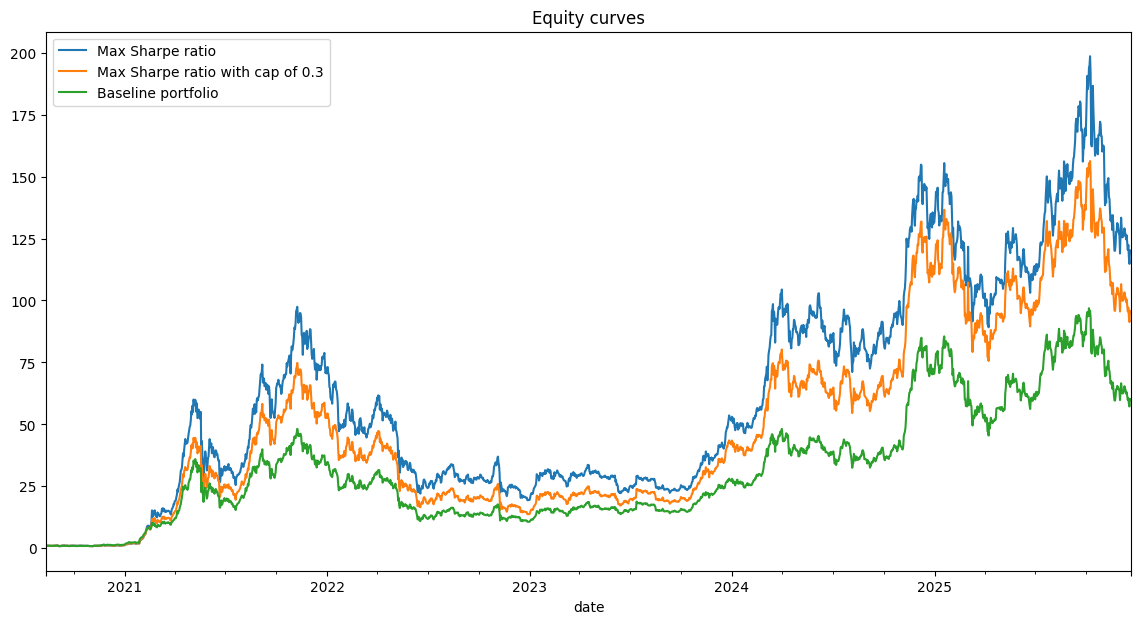

In [130]:
plt.figure(figsize=(14, 7))

eq_uncon.plot(label = 'Max Sharpe ratio')
eq_cap.plot(label = 'Max Sharpe ratio with cap of 0.3')
(1+baseline_portfolio.returns/100).cumprod().plot(label = 'Baseline portfolio')

plt.title('Equity curves')
plt.legend()
plt.show()

- Ok, it was fun, but let's see how it actually works out of sample
- Suppose: 
    - we have year of data, so rolling 365 d. window 
    - we recalculate weights every week (7 d.)
    - we pay comission of 0.075% (Binance spot comission for a regular user) for entry\leave of a position

In [131]:
# I am quite annoyed with .pivot(), so let's create a DataFrame with columns of returns
ret_wide = ret[ret.symbol != 'baseline'].pivot(columns = 'symbol')

In [132]:
ret_wide.columns = ret_wide.columns.droplevel()

In [133]:
dates = []
W_uncon = []
W_cap = []

for i in range(WINDOW_SIZE, ret_wide.shape[0], 7):
    tmp = ret_wide.iloc[(i-WINDOW_SIZE):i]
    dates.append(ret_wide.index[i])
    W_uncon.append(max_sharpe_weights(tmp))
    W_cap.append(max_sharpe_weights(tmp, max_w = 0.3))

In [134]:
W_uncon = pd.DataFrame(W_uncon, index=pd.to_datetime(dates), columns=['w_' + x for x in ret_wide.columns])
W_cap = pd.DataFrame(W_cap, index=pd.to_datetime(dates), columns=['w_' + x for x in ret_wide.columns])

<Figure size 640x480 with 0 Axes>

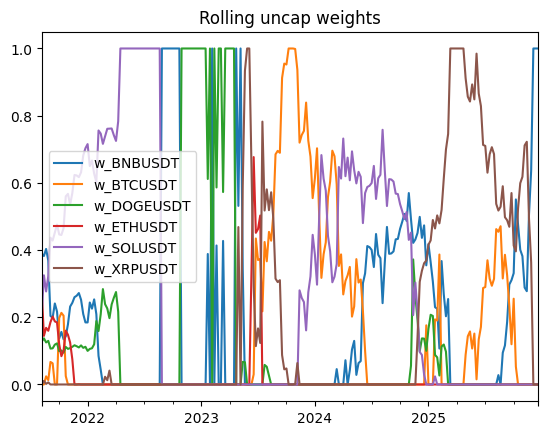

In [135]:
plt.figure()
W_uncon.plot()
plt.title("Rolling uncap weights")
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

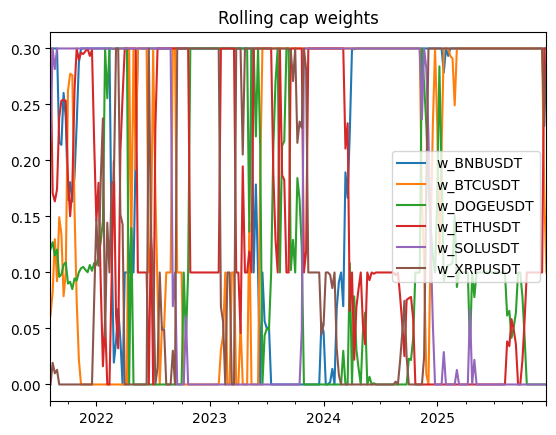

In [136]:
plt.figure()
W_cap.plot()
plt.title("Rolling cap weights")
plt.legend()
plt.show()

- Get ready to pay comissions
- Let's construct portfolios

In [137]:
# We need dates from the beginning of weights calculatio
# Weights calculated for 2021-08-12 are valid for all dates until the next weights calc
uncon_portfolio = pd.concat([
    ret_wide[ret_wide.index >= W_uncon.index.min()],
    W_uncon
    ], 
    axis = 1).ffill()

cap_portfolio = pd.concat([
    ret_wide[ret_wide.index >= W_cap.index.min()],
    W_cap
    ], 
    axis = 1).ffill()

uncon_portfolio_ret = np.diag(uncon_portfolio[option_symbols].values @ uncon_portfolio[['w_' + x for x in option_symbols]].values.T)
cap_portfolio_ret = np.diag(cap_portfolio[option_symbols].values @ cap_portfolio[['w_' + x for x in option_symbols]].values.T)

- I am a very lazy person, so I will just split weekly commisions to daily and substract it from everyday portfolio returns

In [138]:
uncon_portfolio_ret = pd.Series(uncon_portfolio_ret, index=ret_wide[ret_wide.index >= W_uncon.index.min()].index)
uncon_portfolio_ret.name = 'max sharpe uncap'
uncon_portfolio_ret = uncon_portfolio_ret - (2*0.00075)/7

In [139]:
cap_portfolio_ret = pd.Series(cap_portfolio_ret, index=ret_wide[ret_wide.index >= W_cap.index.min()].index)
cap_portfolio_ret.name = 'max sharpe cap'
cap_portfolio_ret = cap_portfolio_ret - (2*0.00075)/7

In [140]:
sharpe_port = pd.concat([uncon_portfolio_ret, cap_portfolio_ret], axis = 1)

In [141]:
ret_wide_all = ret[ret.index>=sharpe_port.index.min()].pivot(columns = 'symbol')
ret_wide_all.columns = ret_wide_all.columns.droplevel()

In [142]:
ret_wide_all = pd.concat([ret_wide_all, sharpe_port], axis = 1)

<Axes: xlabel='date'>

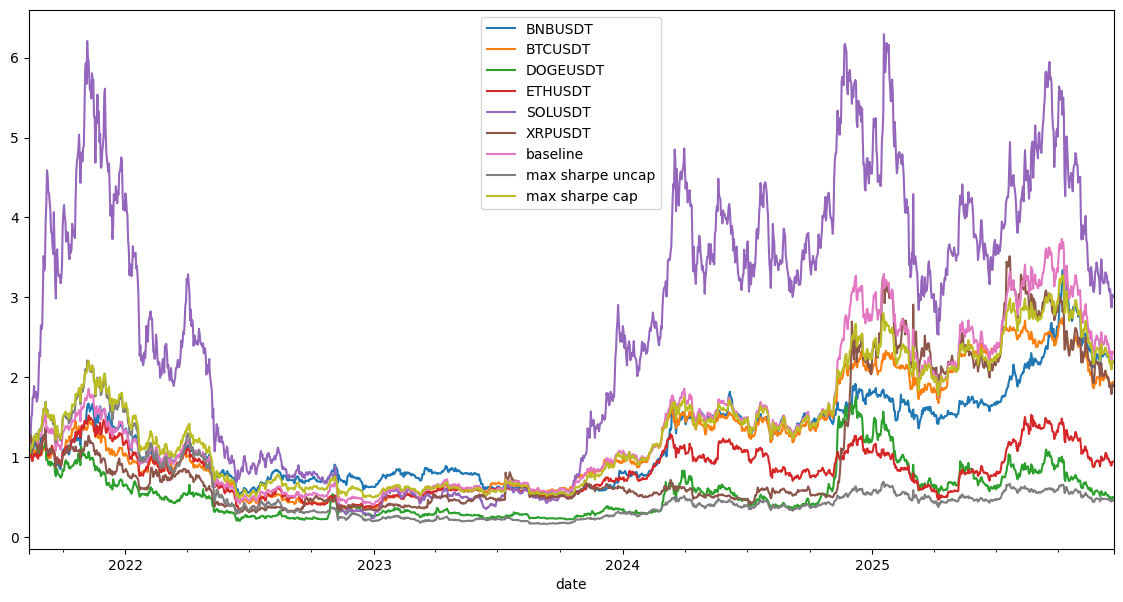

In [143]:
(1+ret_wide_all/100).cumprod().plot(figsize = (14, 7))

In [144]:
ret_wide_all.describe()

,BNBUSDT,BTCUSDT,DOGEUSDT,ETHUSDT,SOLUSDT,XRPUSDT,baseline,max sharpe uncap,max sharpe cap
count,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000,1593.000000
mean,0.099716,0.080279,0.074804,0.065696,0.208675,0.139000,0.111362,0.030863,0.105993
std,3.177772,2.781259,4.938354,3.726470,5.278228,4.605728,3.419674,3.995112,3.366128
min,-18.356750,-15.379839,-22.133687,-17.384268,-42.247744,-18.788271,-20.945668,-23.916507,-17.306261
25%,-1.369335,-1.193866,-2.546125,-1.757235,-2.843990,-1.913222,-1.566779,-1.928447,-1.497998
50%,0.093139,-0.009477,-0.023548,0.009610,-0.073918,0.013648,0.164882,0.088908,0.164216
75%,1.518325,1.359873,2.317161,1.873717,2.930186,1.863905,2.029273,2.023831,1.821346
max,17.302326,14.485583,45.177060,21.880504,32.531438,73.099788,19.260774,25.941120,25.776942


In [145]:
(1+ret_wide_all/100).prod()

BNBUSDT             2.184802
BTCUSDT             1.939610
DOGEUSDT            0.491700
ETHUSDT             0.945452
SOLUSDT             3.008818
XRPUSDT             1.893023
baseline            2.309667
max sharpe uncap    0.456289
max sharpe cap      2.193959
dtype: float64

In [146]:
# ES 95%
ret_wide_all.apply(lambda x:x[x<x.quantile(0.05)].mean(), axis = 0)

BNBUSDT             -7.418848
BTCUSDT             -6.445037
DOGEUSDT           -10.430161
ETHUSDT             -8.471986
SOLUSDT            -10.788479
XRPUSDT             -8.977881
baseline            -8.023110
max sharpe uncap    -9.292242
max sharpe cap      -7.876749
dtype: float64

In [147]:
((1+ret_wide_all/100).prod()-1) / ret_wide_all.apply(lambda x:x[x<x.quantile(0.05)].mean(), axis = 0).abs()

BNBUSDT             0.159702
BTCUSDT             0.145788
DOGEUSDT           -0.048734
ETHUSDT            -0.006439
SOLUSDT             0.186200
XRPUSDT             0.099469
baseline            0.163237
max sharpe uncap   -0.058512
max sharpe cap      0.151580
dtype: float64

In [148]:
ret_wide_all.mean() / ret_wide_all.apply(lambda x:x[x<x.quantile(0.05)].mean(), axis = 0).abs()

BNBUSDT             0.013441
BTCUSDT             0.012456
DOGEUSDT            0.007172
ETHUSDT             0.007755
SOLUSDT             0.019342
XRPUSDT             0.015482
baseline            0.013880
max sharpe uncap    0.003321
max sharpe cap      0.013456
dtype: float64

- Well, this is the reason why we should never trust in-sample results 
- Max Sharpe ratio with capped weighted performs much better that uncapped version
- Though, none beats baseline, equally-weighted, portfolio 

## Momentum 

In [149]:
ema_strategies = df.set_index('date')[['close_price', 'symbol']].groupby('symbol').apply(emama, include_groups=False).reset_index().dropna().set_index('date')[['symbol', 'ema_strategies']].pivot(columns = 'symbol')

In [150]:
ema_strategies.columns = ema_strategies.columns.droplevel()

In [151]:
ema_strategies = ema_strategies.dropna()

- Now, let's think a moment about our strategy
- At some time, for example, 2022-01-01, we see that we have buy signal
- We will buy at a openning price of the following day
- This can be quite important (for crypro not so much, to be honest) for markets where gaps are common thing

In [153]:
df['buy_price'] = df.set_index('date').groupby('symbol')['open_price'].shift(-1).reset_index(drop=True)

- As I said earlier, I will be using volatility weightening 
- I am gonna use a rolling window of 365 d. of returns to calc standard deviation 

In [154]:
volatility = df.set_index('date')[['symbol', 'close_price']].groupby('symbol').apply(lambda x: x/x.shift()-1).reset_index().set_index('date').groupby('symbol').rolling(WINDOW_SIZE).std().reset_index().rename(columns = {'close_price':'volatility'})

In [155]:
df = pd.merge(df, volatility, how = 'inner', on = ['date', 'symbol'])

In [156]:
momentum_data = df.dropna().reset_index(drop=True)

- In order to have comparable with Markowitz optimal portfolio results we will begin at the same date

In [157]:
start_date = sharpe_port.index.min()

- Let's change shape of our EMA strategy signals
- If we have 0 -> we are not in position
- If we have -1 -> we are not in position
- If we have 1 -> we are in position until -1 occurs

In [158]:
ema_strategies = ema_strategies[ema_strategies.index>=start_date].replace({0:np.nan}).ffill().replace({-1:0}).fillna(0)

- Now we need weights which are a product of signal and volatility weight

In [160]:
volatility_w = momentum_data[momentum_data.date>=start_date].set_index('date')[['symbol', 'volatility']].pivot(columns = 'symbol')

In [163]:
volatility_w = (volatility_w * ema_strategies).dropna()
volatility_w.columns = volatility_w.columns.droplevel()

In [164]:
volatility_w=(1/volatility_w).replace({np.inf:0})

In [165]:
volatility_w['total'] = volatility_w.sum(axis=1)

In [166]:
volatility_w = volatility_w.apply(lambda x: x / x.total, axis = 1).fillna(0).drop(columns='total', axis = 1)

In [170]:
volatility_w_delta = (volatility_w - volatility_w.shift()).fillna(0)

In [171]:
volatility_w_delta = ~(volatility_w_delta==0).all(axis=1)

In [172]:
momentum_fees = volatility_w_delta.replace({False:0.0, True:2*0.00075})

C:\Users\Timur\AppData\Local\Temp\ipykernel_15896\3694626026.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  momentum_fees = volatility_w_delta.replace({False:0.0, True:2*0.00075})


- Ok, now we have volatilty inverse weights with EMA signals
- Remember what we did with buy price? We need it now to calc returns
- Second thing to remember except for buy price is that our signal is forward looking. For example, if we have buy signal on 12th of Sep., we actually buy at open price of 13th of Sep., if we have sell signal we also selling at price of next day

In [210]:
momentum_ret = df.set_index('date')[['symbol', 'buy_price']].groupby('symbol').apply(lambda x: (x.shift(-1)/x-1)*100).reset_index().dropna().set_index('date')

In [211]:
momentum_ret = momentum_ret[momentum_ret.index>=start_date]

In [212]:
momentum_ret = momentum_ret.pivot(columns='symbol')
momentum_ret.columns = momentum_ret.columns.droplevel()

In [213]:
momentum_port_ret = pd.Series(np.diag(momentum_ret.values @ volatility_w.values.T), index = momentum_ret.index)
momentum_port_ret = momentum_port_ret - momentum_fees
momentum_port_ret.name = 'momentum portfolio'

<Axes: xlabel='date'>

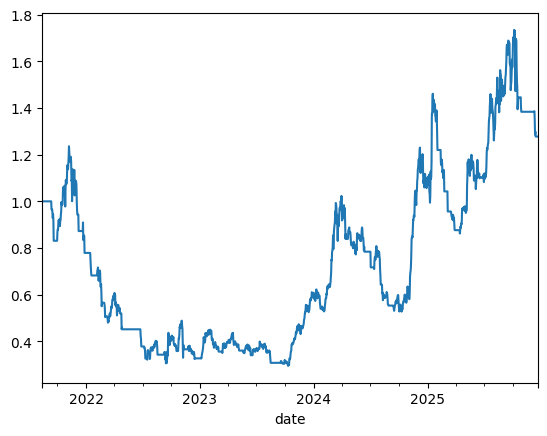

In [215]:
(1+momentum_port_ret/100).cumprod().plot()

In [218]:
ret_wide_all = pd.concat([ret_wide_all, momentum_port_ret], axis = 1).dropna()

In [219]:
(1+ret_wide_all/100).prod()

BNBUSDT               2.189917
BTCUSDT               1.936607
DOGEUSDT              0.499981
ETHUSDT               0.942731
SOLUSDT               3.033805
XRPUSDT               1.889362
baseline              2.317662
max sharpe uncap      0.457359
max sharpe cap        2.191917
momentum portfolio    1.277671
dtype: float64

In [220]:
# ES 95%
ret_wide_all.apply(lambda x:x[x<x.quantile(0.05)].mean(), axis = 0)

BNBUSDT               -7.418848
BTCUSDT               -6.445037
DOGEUSDT             -10.430161
ETHUSDT               -8.471986
SOLUSDT              -10.788479
XRPUSDT               -8.977881
baseline              -8.023110
max sharpe uncap      -9.292242
max sharpe cap        -7.876749
momentum portfolio    -6.814430
dtype: float64

In [221]:
((1+ret_wide_all/100).prod()-1) / ret_wide_all.apply(lambda x:x[x<x.quantile(0.05)].mean(), axis = 0).abs()

BNBUSDT               0.160391
BTCUSDT               0.145322
DOGEUSDT             -0.047940
ETHUSDT              -0.006760
SOLUSDT               0.188516
XRPUSDT               0.099061
baseline              0.164233
max sharpe uncap     -0.058397
max sharpe cap        0.151321
momentum portfolio    0.040748
dtype: float64

In [222]:
ret_wide_all.mean() / ret_wide_all.apply(lambda x:x[x<x.quantile(0.05)].mean(), axis = 0).abs()

BNBUSDT               0.013478
BTCUSDT               0.012456
DOGEUSDT              0.007281
ETHUSDT               0.007743
SOLUSDT               0.019415
XRPUSDT               0.015487
baseline              0.013925
max sharpe uncap      0.003341
max sharpe cap        0.013466
momentum portfolio    0.007897
dtype: float64

<Axes: xlabel='date'>

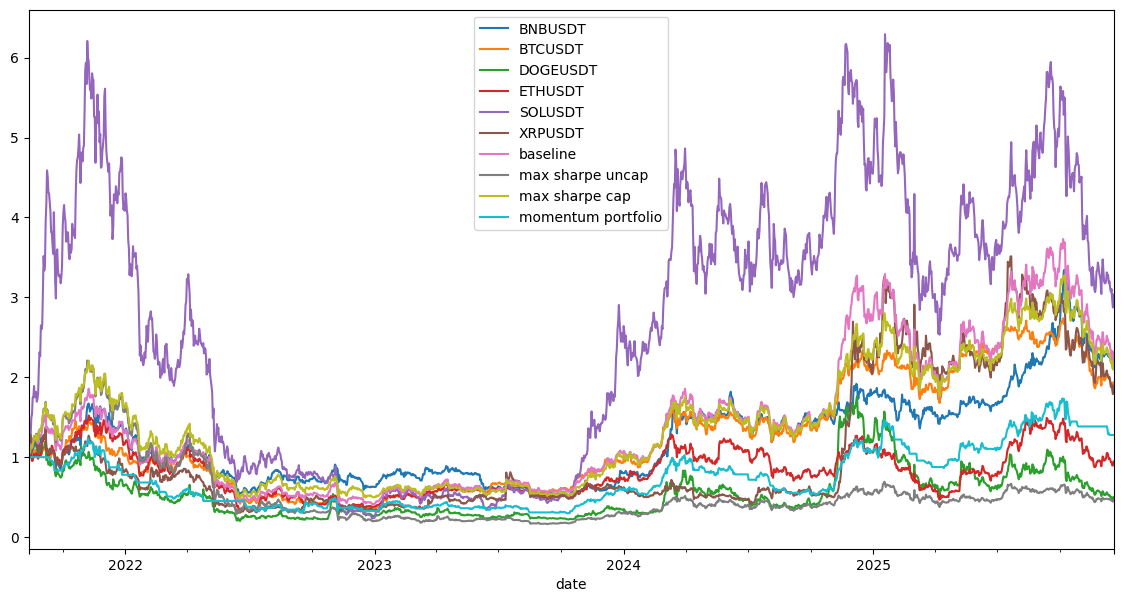

In [223]:
(1+ret_wide_all/100).cumprod().plot(figsize = (14, 7))

- Well, we couldn't beat baseline with simple techniques 
- Let's try something more interesting: SARIMAX

## SARIMAX

In [246]:
model = sm.tsa.statespace.SARIMAX(ret[ret.symbol == 'BTCUSDT']['returns'], trend='c', order=(1,0,1))

c:\Users\Timur\anaconda3\envs\trading\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Timur\anaconda3\envs\trading\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [247]:
res = model.fit()

In [248]:
print(res.summary())

                               SARIMAX Results                                
Dep. Variable:                returns   No. Observations:                 1958
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -4972.119
Date:                Mon, 22 Dec 2025   AIC                           9952.238
Time:                        21:42:37   BIC                           9974.557
Sample:                    08-12-2020   HQIC                          9960.442
                         - 12-21-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.2038      0.121      1.678      0.093      -0.034       0.442
ar.L1         -0.3450      0.486     -0.710      0.477      -1.297       0.607
ma.L1          0.3106      0.491      0.633      0.5

In [249]:
res.forecast(steps=1)

2025-12-22    0.151379
Freq: D, dtype: float64

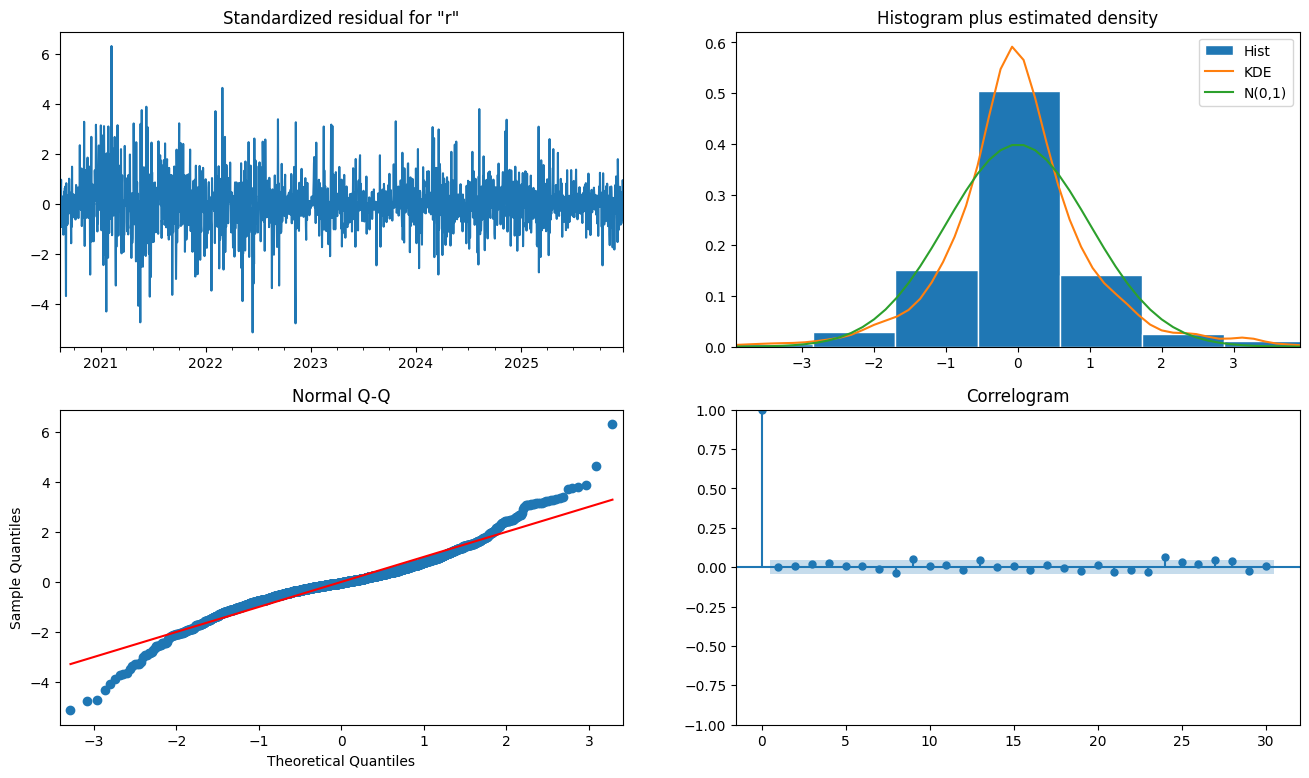

In [250]:
fig = plt.figure(figsize=(16, 9))
fig = res.plot_diagnostics(lags=30, fig=fig)

- It is an example for BTC and ARIMA(1,0, 1)
- It looks horrible
- As we saw earlier with such skewness and kurtosis "normal" statistical methods perform terrible